# Persona Demographic Bias Analysis
Tests for unintentional associations between demographic variables in the 500-persona pool.


In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, f_oneway
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path("..").resolve()))

PERSONA_DIR = Path("../data/output/craft_persona_20260501_184525")

rows = []
for fp in sorted(PERSONA_DIR.glob("experiment_*.json")):
    try:
        with open(fp, encoding="utf-8") as f:
            data = json.load(f)
        demo = data.get("demographics", {})
        demo["persona_id"] = data.get("persona_id")
        rows.append(demo)
    except Exception:
        pass

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} personas")
print(df.dtypes)
df.head(3)

Loaded 500 personas
age                     int64
gender                 object
ethnicity              object
relationship_status    object
occupation             object
trauma_type            object
pcl5                    int64
persona_id              int64
dtype: object


,age,gender,ethnicity,relationship_status,occupation,trauma_type,pcl5,persona_id
0,58,Male,South Asian,Married,Bomb Disposal Technician,Child's life-threatening illness,39,1
1,30,Female,Oceania,Married,Plumber,Physical abuse by caregiver (childhood),34,10
2,39,Male,Oceania,Divorced,Airline Pilot,Police,79,100


In [2]:

# ── Occupation grouping ────────────────────────────────────────────────────────
HIGH_RISK_OCCUPATIONS = {
    "Soldier", "Firefighter", "Police Officer", "Paramedic",
    "Military Officer", "Combat Medic", "Security Guard",
}

def occupation_group(occ):
    if pd.isna(occ):
        return "Unknown"
    return "High-risk" if occ in HIGH_RISK_OCCUPATIONS else "Civilian"

df["occupation_group"] = df["occupation"].apply(occupation_group)

# ── Age bins ──────────────────────────────────────────────────────────────────
df["age_bin"] = pd.cut(df["age"], bins=[17, 30, 42, 54, 66, 80],
                        labels=["18-30", "31-42", "43-54", "55-66", "67-80"])

print("Occupation groups:", df["occupation_group"].value_counts().to_dict())
print("Age bins:         ", df["age_bin"].value_counts().sort_index().to_dict())

Occupation groups: {'Civilian': 479, 'High-risk': 21}
Age bins:          {'18-30': 104, '31-42': 102, '43-54': 97, '55-66': 91, '67-80': 106}


In [3]:
# ── Chi-square helper ─────────────────────────────────────────────────────────

def chi_square_test(df, var1, var2, label):
    ct = pd.crosstab(df[var1], df[var2])
    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"{label}")
    print(f"  chi2={chi2:.2f}, df={dof}, p={p:.4f} {sig}, Cramér's V={cramers_v:.3f}")
    print()
    return {"test": label, "chi2": round(chi2,2), "df": dof, "p": round(p,4),
            "sig": sig, "cramers_v": round(cramers_v,3)}

results = []

print("=" * 60)
print("CHI-SQUARE TESTS")
print("=" * 60)
print()
results.append(chi_square_test(df, "gender",           "trauma_type",      "1. Gender × Trauma type"))
results.append(chi_square_test(df, "gender",           "occupation_group",  "2. Gender × Occupation group"))
results.append(chi_square_test(df, "ethnicity",        "trauma_type",      "3. Ethnicity × Trauma type"))
results.append(chi_square_test(df, "ethnicity",        "occupation_group",  "4. Ethnicity × Occupation group"))
results.append(chi_square_test(df, "age_bin",          "trauma_type",      "5. Age (binned) × Trauma type"))
results.append(chi_square_test(df, "occupation_group", "trauma_type",      "6. Occupation group × Trauma type"))

CHI-SQUARE TESTS

1. Gender × Trauma type
  chi2=58.36, df=56, p=0.3888 ns, Cramér's V=0.242

2. Gender × Occupation group
  chi2=1.89, df=2, p=0.3882 ns, Cramér's V=0.062

3. Ethnicity × Trauma type
  chi2=186.10, df=196, p=0.6825 ns, Cramér's V=0.231

4. Ethnicity × Occupation group
  chi2=5.29, df=7, p=0.6250 ns, Cramér's V=0.103

5. Age (binned) × Trauma type
  chi2=135.77, df=112, p=0.0628 ns, Cramér's V=0.261

6. Occupation group × Trauma type
  chi2=27.97, df=28, p=0.4660 ns, Cramér's V=0.237



In [4]:
print("=" * 60)
print("t-TEST & ANOVA — PCL-5")
print("=" * 60)
print()

# 7. Gender × PCL-5 (t-test)
groups_gender = [g["pcl5"].dropna().values for _, g in df.groupby("gender")]
if len(groups_gender) == 2:
    t, p = ttest_ind(*groups_gender)
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"7. Gender × PCL-5  (t-test)")
    print(f"   t={t:.3f}, p={p:.4f} {sig}")
    for name, g in df.groupby("gender"):
        print(f"   {name}: mean={g['pcl5'].mean():.1f}, sd={g['pcl5'].std():.1f}")
    results.append({"test": "7. Gender × PCL-5", "statistic": round(t,3), "p": round(p,4), "sig": sig})
print()

# 8. Ethnicity × PCL-5 (ANOVA)
groups_eth = [g["pcl5"].dropna().values for _, g in df.groupby("ethnicity")]
F, p = f_oneway(*groups_eth)
sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
print(f"8. Ethnicity × PCL-5  (one-way ANOVA)")
print(f"   F={F:.3f}, p={p:.4f} {sig}")
for name, g in df.groupby("ethnicity"):
    print(f"   {name}: mean={g['pcl5'].mean():.1f}, sd={g['pcl5'].std():.1f}")
results.append({"test": "8. Ethnicity × PCL-5", "statistic": round(F,3), "p": round(p,4), "sig": sig})
print()

# 9. Trauma type × PCL-5 (ANOVA)
groups_tr = [g["pcl5"].dropna().values for _, g in df.groupby("trauma_type")]
F, p = f_oneway(*groups_tr)
sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
print(f"9. Trauma type × PCL-5  (one-way ANOVA)")
print(f"   F={F:.3f}, p={p:.4f} {sig}")
for name, g in df.groupby("trauma_type"):
    print(f"   {name}: mean={g['pcl5'].mean():.1f}, sd={g['pcl5'].std():.1f}")
results.append({"test": "9. Trauma type × PCL-5", "statistic": round(F,3), "p": round(p,4), "sig": sig})

t-TEST & ANOVA — PCL-5


8. Ethnicity × PCL-5  (one-way ANOVA)
   F=1.863, p=0.0736 ns
   African: mean=61.8, sd=12.7
   European: mean=58.0, sd=13.5
   Latin American: mean=54.4, sd=13.9
   Middle Eastern: mean=55.6, sd=15.2
   North American: mean=56.2, sd=13.3
   Oceania: mean=60.3, sd=13.7
   South Asian: mean=58.3, sd=13.7
   South Eastern Asian: mean=57.9, sd=14.6

9. Trauma type × PCL-5  (one-way ANOVA)
   F=0.985, p=0.4887 ns
   Accidentally caused serious injury to another: mean=61.3, sd=11.0
   Assault: mean=60.3, sd=15.2
   Captivity: mean=57.2, sd=12.2
   Child's life-threatening illness: mean=54.3, sd=17.2
   Civilian in war zone: mean=56.2, sd=15.4
   Combat: mean=59.6, sd=16.9
   Life-threatening accident: mean=58.2, sd=15.6
   Life-threatening illness: mean=61.4, sd=13.4
   Life-threatening motor vehicle collision: mean=53.1, sd=15.3
   Man-made disaster: mean=60.2, sd=14.9
   Military: mean=60.0, sd=13.7
   Mugging or robbery: mean=61.0, sd=11.6
   Natural disaster: me

In [5]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame(results)[["test", "p", "sig", "cramers_v"] if "cramers_v" in results[0] else ["test","p","sig"]]
print("\nSUMMARY")
print(summary.to_string(index=False))


SUMMARY
                             test      p sig  cramers_v
          1. Gender × Trauma type 0.3888  ns      0.242
     2. Gender × Occupation group 0.3882  ns      0.062
       3. Ethnicity × Trauma type 0.6825  ns      0.231
  4. Ethnicity × Occupation group 0.6250  ns      0.103
    5. Age (binned) × Trauma type 0.0628  ns      0.261
6. Occupation group × Trauma type 0.4660  ns      0.237
             8. Ethnicity × PCL-5 0.0736  ns        NaN
           9. Trauma type × PCL-5 0.4887  ns        NaN


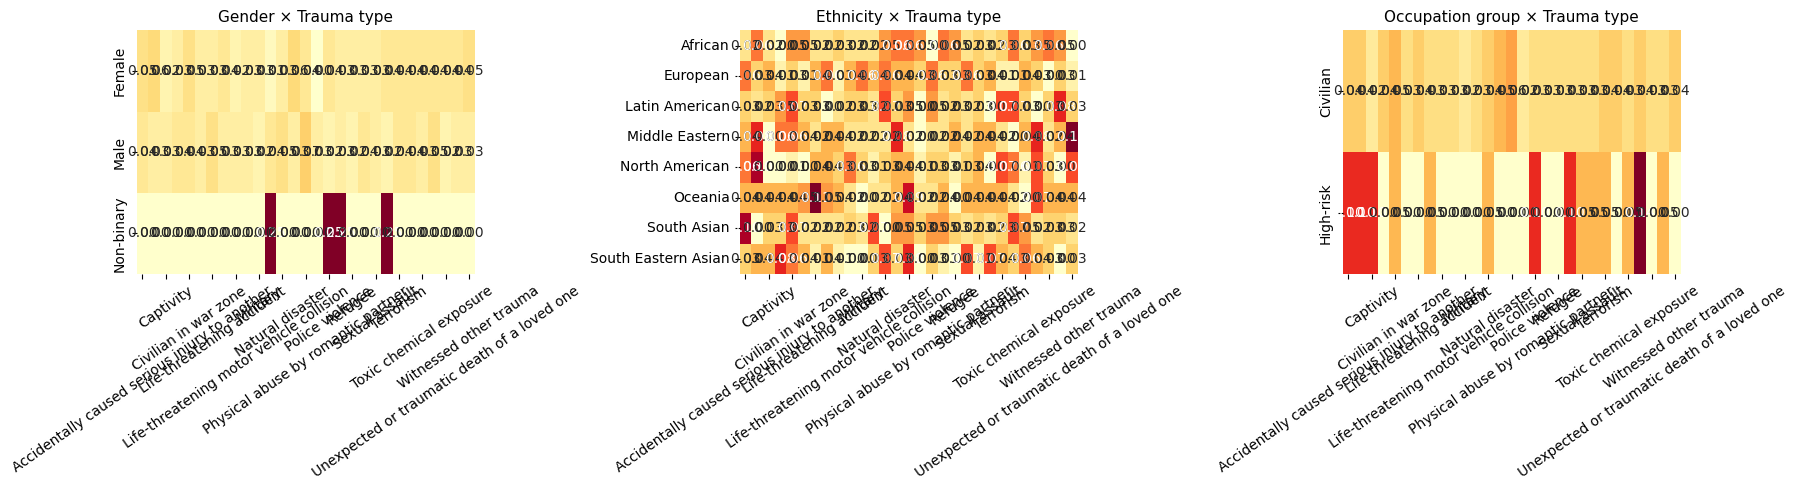

In [6]:
# ── Heatmaps for significant chi-square pairs ─────────────────────────────────
pairs = [
    ("gender",           "trauma_type",      "Gender × Trauma type"),
    ("ethnicity",        "trauma_type",      "Ethnicity × Trauma type"),
    ("occupation_group", "trauma_type",      "Occupation group × Trauma type"),
]

fig, axes = plt.subplots(1, len(pairs), figsize=(18, 5))
for ax, (v1, v2, title) in zip(axes, pairs):
    ct = pd.crosstab(df[v1], df[v2], normalize="index").round(2)
    sns.heatmap(ct, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax, cbar=False)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.savefig("persona_bias_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

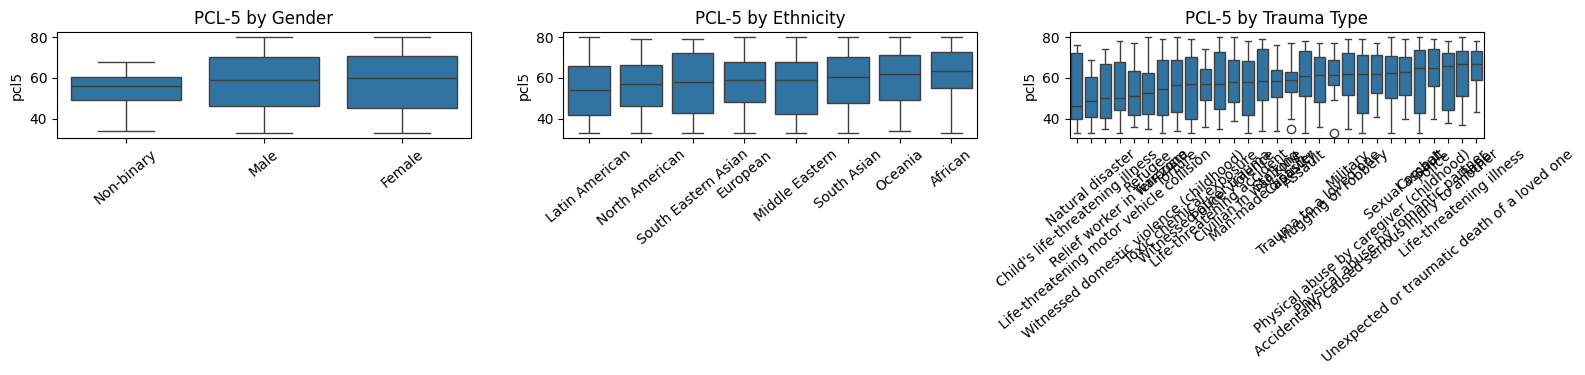

In [9]:
# ── PCL-5 distributions by group ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, var in zip(axes, ["gender", "ethnicity", "trauma_type"]):
    order = df.groupby(var)["pcl5"].median().sort_values().index.tolist()
    sns.boxplot(data=df, x=var, y="pcl5", order=order, ax=ax)
    ax.set_title(f"PCL-5 by {var.replace('_',' ').title()}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=40)

plt.suptitle("")
plt.tight_layout()
plt.savefig("pcl5_distributions.png", dpi=150, bbox_inches="tight")
plt.show()